# Hand classifier (MobileNet Finetuned)
This model uses a pretrained model with most weights frozen and only trains the upper layers.  

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

2026-04-27 10:07:13.143988: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow


In [2]:
from sklearn.model_selection import train_test_split
batch_size_n = 4
img_size = (224, 224)

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    'images/train',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    validation_split=0.177, # ensures validation and test sets are equal size
    subset='both',
    shuffle=True,
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    'images/test',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    shuffle=False)

Found 255 files belonging to 5 classes.
Using 210 files for training.
Using 45 files for validation.


I0000 00:00:1777273638.997392   13079 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 45 files belonging to 5 classes.


## Building the model
The pretrained models tested with this dataset were VGG16 and MobileNetV2.  
MobileNetV2 was chosen as the final model because it achieved slightly better results.

In [3]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras import Sequential
from keras import layers
from keras.optimizers import Adam
num_classes = 5

conv_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# freeze all training
conv_base.trainable = False

In [4]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [5]:
from keras.optimizers import Adam
inputs = layers.Input(shape=(224, 224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = conv_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
model.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [7]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/5


2026-04-27 10:07:30.484217: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000


53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.2762 - loss: 2.0841 - val_accuracy: 0.3333 - val_loss: 1.3441
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.4190 - loss: 1.3595 - val_accuracy: 0.3778 - val_loss: 1.3990
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ -74s -1418617us/step - accuracy: 0.4619 - loss: 1.1890 - val_accuracy: 0.5111 - val_loss: 1.1742
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5286 - loss: 1.0689 - val_accuracy: 0.5111 - val_loss: 1.0442
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5476 - loss: 1.0513 - val_accuracy: 0.4667 - val_loss: 1.0481


In [8]:
conv_base.trainable = True

for layer in conv_base.layers[:-4]:
    layer.trainable = False
    
for layer in conv_base.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])    

In [9]:
from keras.callbacks import EarlyStopping

finetuned_history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.5333 - loss: 1.2406 - val_accuracy: 0.4667 - val_loss: 1.0423
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5238 - loss: 1.2212 - val_accuracy: 0.4444 - val_loss: 1.0443
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.5286 - loss: 1.1452 - val_accuracy: 0.4667 - val_loss: 1.0445
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5000 - loss: 1.2584 - val_accuracy: 0.4444 - val_loss: 1.0357
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5381 - loss: 1.1932 - val_accuracy: 0.4667 - val_loss: 1.0248
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.4762 - loss: 1.2781 - val_accuracy: 0.4667 - val_loss: 1.0214
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.5000 - loss: 1.1592 - val_accuracy: 0.5111 - val_loss: 1.0082
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.5762 - loss: 1.0234 - val_accuracy: 0.5111 -

In [10]:
images = []
labels = []
class_names = ['1 finger', '2 fingers', '3 fingers', '4 fingers', '5 fingers']

for image_batch, label_batch in test_dataset:
    images.append(image_batch.numpy())
    labels.append(label_batch.numpy())

images = np.concatenate(images)
labels = np.concatenate(labels)

2026-04-27 10:09:17.414660: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
def show_example_images_and_predictions(predicted_labels):
    plt.figure(figsize=(15, 8))
    
    for i in range(20):
        plt.subplot(4, 5, i + 1)
    
        plt.imshow(images[i].astype("uint8"))
    
        true_label = y_true_classes[i]
        pred_label = predicted_labels[i]
    
        color = "green" if true_label == pred_label else "red"
    
        plt.title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            color=color
        )
    
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

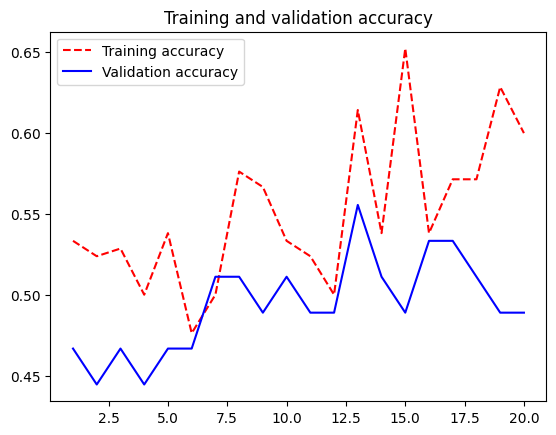

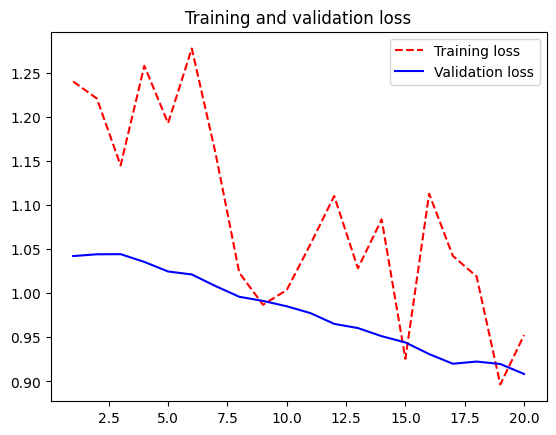

In [12]:
acc = finetuned_history.history["accuracy"]
val_acc = finetuned_history.history["val_accuracy"]
loss = finetuned_history.history["loss"]
val_loss = finetuned_history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [13]:
loss, acc = model.evaluate(test_dataset, verbose=0)
print(f"The model's test accuracy is {acc}")

The model's test accuracy is 0.4888888895511627


In [20]:
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.concatenate([y for x, y in test_dataset], axis=0)

12/12 ━━━━━━━━━━━━━━━━━━━━ 79s 7s/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


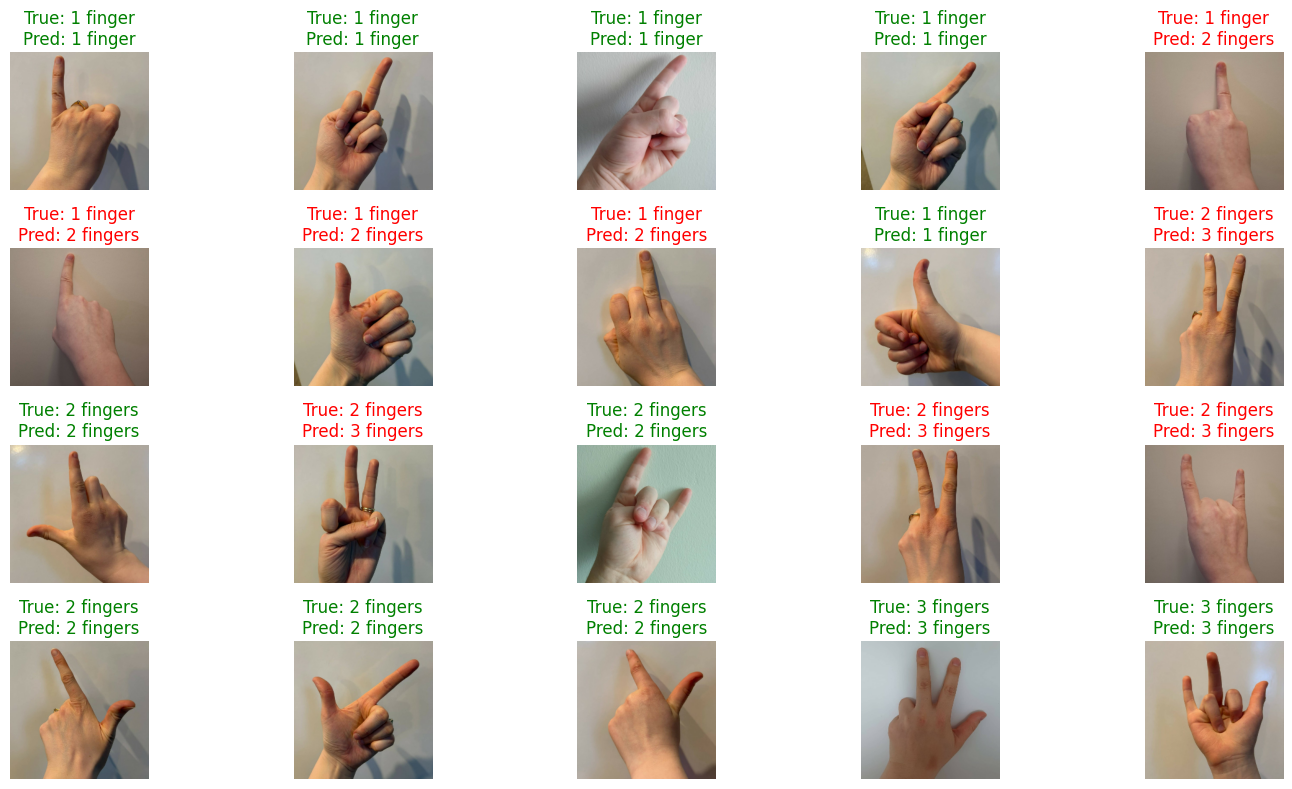

In [21]:
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
show_example_images_and_predictions(y_pred_classes)